#### ARIMA and GARCH

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf



In [2]:

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load your saved data
ftse = pd.read_csv('data/ftse_processed.csv', index_col='Date', parse_dates=True)
sp500 = pd.read_csv('data/sp500_processed.csv', index_col='Date', parse_dates=True)

ftse.head()

,Close,High,Low,Open,Volume,log_return,volatility_21d,volatility_annualized
Date,,,,,,,,
2015-01-05,6417.200195,6576.700195,6404.500000,6547.799805,728001100,-0.020147,NaN,NaN
2015-01-06,6366.500000,6452.700195,6328.600098,6417.200195,769463100,-0.007932,NaN,NaN
2015-01-07,6419.799805,6459.700195,6366.500000,6366.500000,688211500,0.008337,NaN,NaN
2015-01-08,6570.000000,6580.799805,6419.799805,6419.799805,882740200,0.023127,NaN,NaN
2015-01-09,6501.100098,6570.200195,6471.399902,6570.000000,738488500,-0.010542,NaN,NaN


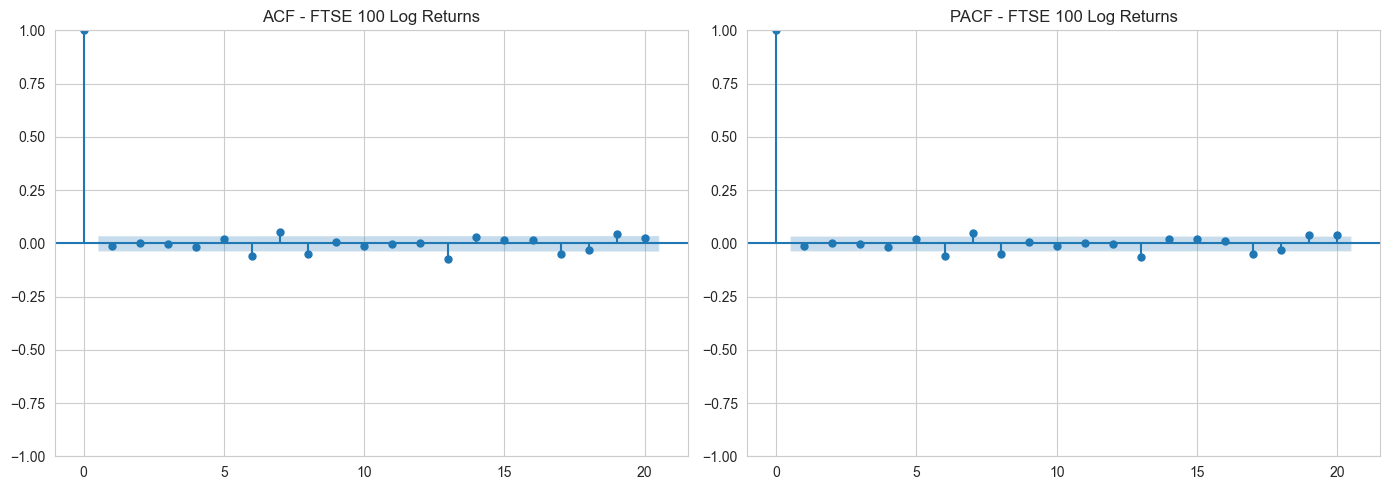

In [3]:
#ACF and PACF plots — choosing ARIMA parameters properly

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(ftse['log_return'].dropna(), lags=20, ax=axes[0])
axes[0].set_title('ACF - FTSE 100 Log Returns')

plot_pacf(ftse['log_return'].dropna(), lags=20, ax=axes[1])
axes[1].set_title('PACF - FTSE 100 Log Returns')

plt.tight_layout()
plt.show()

In [4]:
# Fitting ARIMA(1,0,0) on FTSE log returns
model_ftse = ARIMA(ftse['log_return'].dropna(), order=(1, 0, 0))
fitted_ftse = model_ftse.fit()
print(fitted_ftse.summary())

C:\Users\ASUS\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ASUS\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ASUS\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                 2924
Model:                 ARIMA(1, 0, 0)   Log Likelihood                9414.543
Date:                Thu, 06 Aug 2026   AIC                         -18823.086
Time:                        16:44:39   BIC                         -18805.143
Sample:                             0   HQIC                        -18816.623
                               - 2924                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.914      0.361      -0.000       0.001
ar.L1         -0.0124      0.010     -1.273      0.203      -0.031       0.007
sigma2      9.343e-05   9.12e-07    102.453      0.0

In [5]:
#same for S&P 500
model_sp500 = ARIMA(sp500['log_return'].dropna(), order=(1, 0, 0))
fitted_sp500 = model_sp500.fit()
print(fitted_sp500.summary())

C:\Users\ASUS\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ASUS\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ASUS\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                 2910
Model:                 ARIMA(1, 0, 0)   Log Likelihood                8968.507
Date:                Thu, 06 Aug 2026   AIC                         -17931.013
Time:                        16:47:30   BIC                         -17913.085
Sample:                             0   HQIC                        -17924.555
                               - 2910                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      2.347      0.019    7.32e-05       0.001
ar.L1         -0.1297      0.007    -18.069      0.000      -0.144      -0.116
sigma2         0.0001   1.23e-06    100.096      0.0

In [6]:
#GARCH — modeling the volatility itself

from arch import arch_model

# GARCH(1,1) is the standard starting point — almost universally used in practice
# Scale returns by 100 for numerical stability (arch library convention)
garch_ftse = arch_model(ftse['log_return'].dropna() * 100, vol='Garch', p=1, q=1, dist='t')
fitted_garch_ftse = garch_ftse.fit(disp='off')
print(fitted_garch_ftse.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   log_return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3469.78
Distribution:      Standardized Student's t   AIC:                           6949.55
Method:                  Maximum Likelihood   BIC:                           6979.46
                                              No. Observations:                 2924
Date:                      Thu, Aug 06 2026   Df Residuals:                     2923
Time:                              16:49:24   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

In [8]:
# for S&P 500

garch_sp500 = arch_model(sp500['log_return'].dropna() * 100, vol='Garch', p=1, q=1, dist='t')
fitted_garch_sp500 = garch_sp500.fit(disp='off')
print(fitted_garch_sp500.summary())


                        Constant Mean - GARCH Model Results                         
Dep. Variable:                   log_return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -3657.05
Distribution:      Standardized Student's t   AIC:                           7324.10
Method:                  Maximum Likelihood   BIC:                           7353.98
                                              No. Observations:                 2910
Date:                      Thu, Aug 06 2026   Df Residuals:                     2909
Time:                              16:50:53   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

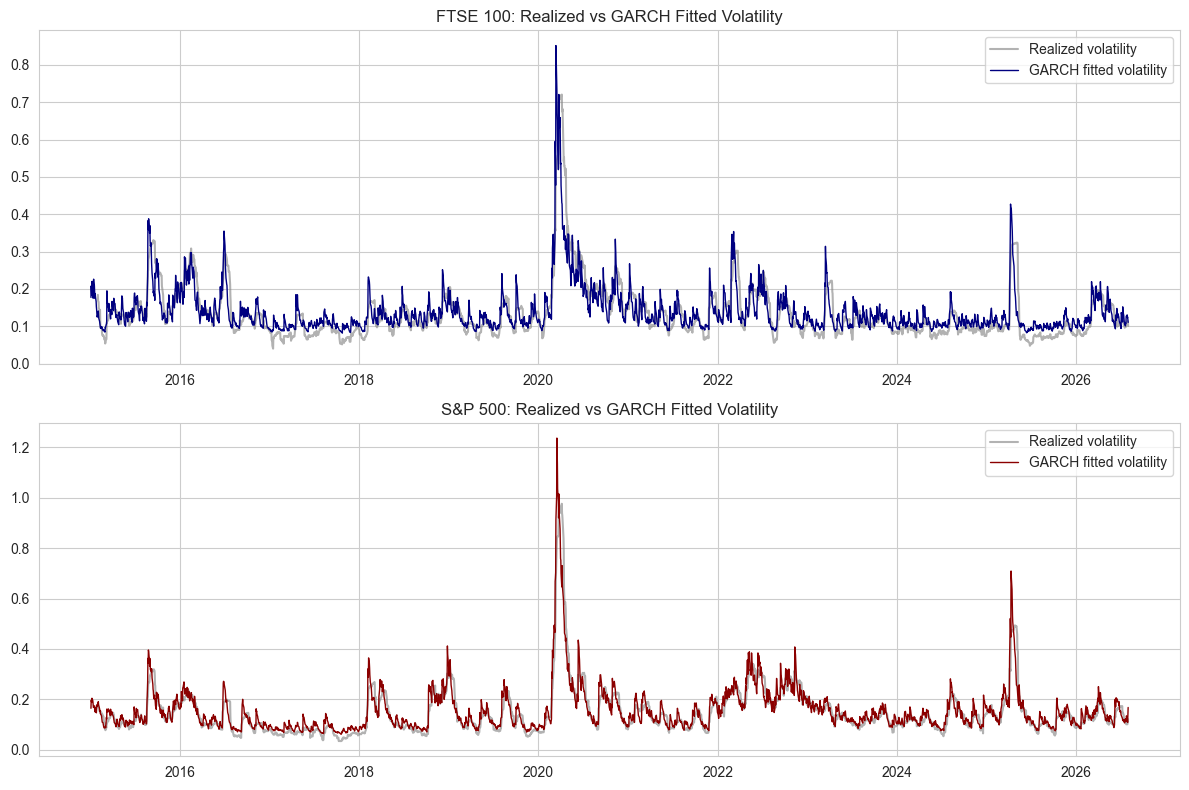

In [9]:
#Extracting fitted volatility and comparing against realized volatility

# Extract GARCH's conditional volatility (undo the *100 scaling, then annualize)
ftse_garch_vol = fitted_garch_ftse.conditional_volatility / 100 * np.sqrt(252)
sp500_garch_vol = fitted_garch_sp500.conditional_volatility / 100 * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(ftse.index[-len(ftse_garch_vol):], ftse['volatility_annualized'].iloc[-len(ftse_garch_vol):], 
             label='Realized volatility', color='gray', alpha=0.6)
axes[0].plot(ftse.index[-len(ftse_garch_vol):], ftse_garch_vol, 
             label='GARCH fitted volatility', color='navy', linewidth=1)
axes[0].set_title('FTSE 100: Realized vs GARCH Fitted Volatility')
axes[0].legend()

axes[1].plot(sp500.index[-len(sp500_garch_vol):], sp500['volatility_annualized'].iloc[-len(sp500_garch_vol):], 
             label='Realized volatility', color='gray', alpha=0.6)
axes[1].plot(sp500.index[-len(sp500_garch_vol):], sp500_garch_vol, 
             label='GARCH fitted volatility', color='darkred', linewidth=1)
axes[1].set_title('S&P 500: Realized vs GARCH Fitted Volatility')
axes[1].legend()

plt.tight_layout()
plt.show()